# SHAP and Augmented Dickey-Fuller Test

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import shap

from config.config import Config
from src.evaluation import adf_test, SHAPExplainer
from src.train import ModelTrainer

In [2]:
cfg = Config.load()

In [3]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
adj = pd.to_numeric(df_full["adj_close"], errors="coerce")

In [4]:
print(adf_test(df_full["adj_close"], "adj_close"))

ADF Test on 'adj_close'
----------------------------------------
Test Statistic : -0.3789
p-value        : 0.9136
Lags Used      : 5
Observations   : 1953
----------------------------------------
Critical Value 1% : -3.4337
Critical Value 5% : -2.8630
Critical Value 10% : -2.5676



In [5]:
print(adf_test(np.log(adj / adj.shift(1)), "log_return"))

ADF Test on 'log_return'
----------------------------------------
Test Statistic : -9.7985
p-value        : 6.082e-17
Lags Used      : 21
Observations   : 1936
----------------------------------------
Critical Value 1% : -3.4337
Critical Value 5% : -2.8630
Critical Value 10% : -2.5676



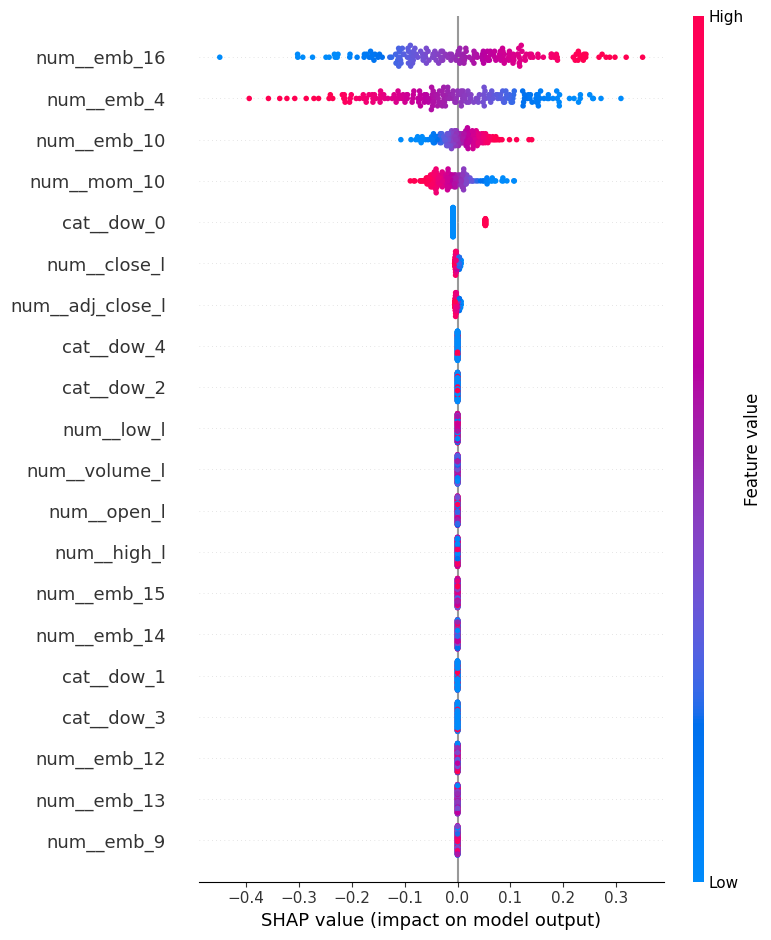

In [6]:
model_path = Path(cfg.data.models_dir) / "linreg.pkl"
model, preprocessor, y_scaler, _ = ModelTrainer.load(str(model_path))

X_test = pd.read_parquet(Path(cfg.data.processed_dir) / "linreg_X_test.parquet")
X_test_proc = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

explainer = SHAPExplainer(
    model=model,
    preprocessor=preprocessor,
    background_data=X_test.sample(n=100, random_state=cfg.runtime.seed),
    seed=cfg.runtime.seed,
    mode="linear"
)

shap_values = explainer.explain(X_test)

shap.summary_plot(
    shap_values[0],
    X_test_proc,
    feature_names=feature_names,
    show=True
)